In [1]:
!pip install pyarrow fastparquet pandas duckdb pandas -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import duckdb 
import numpy as np
import matplotlib.pyplot as plt

duckdb.sql("DESCRIBE SELECT * FROM '/Volumes/falcon/gsoc_2026/data/QCDToGGQQ_IMGjet_RH1all_jet0_run2_n55494_LR.parquet';")

┌─────────────┬──────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │ column_type  │  null   │   key   │ default │  extra  │
│   varchar   │   varchar    │ varchar │ varchar │ varchar │ varchar │
├─────────────┼──────────────┼─────────┼─────────┼─────────┼─────────┤
│ X_jets_LR   │ DOUBLE[][][] │ YES     │ NULL    │ NULL    │ NULL    │
│ X_jets      │ DOUBLE[][][] │ YES     │ NULL    │ NULL    │ NULL    │
│ pt          │ DOUBLE       │ YES     │ NULL    │ NULL    │ NULL    │
│ m0          │ DOUBLE       │ YES     │ NULL    │ NULL    │ NULL    │
│ y           │ DOUBLE       │ YES     │ NULL    │ NULL    │ NULL    │
└─────────────┴──────────────┴─────────┴─────────┴─────────┴─────────┘

In [ ]:
con = duckdb.connect()

df_duck = con.execute("""
SELECT 
    X_jets_LR,
    X_jets,
    y
FROM '/Volumes/falcon/gsoc_2026/data/QCDToGGQQ_IMGjet_RH1all_jet0_run2_n55494_LR.parquet'
LIMIT 1000
""").fetch_df()

x_lr = df_duck["X_jets_LR"][0]
x_hr = df_duck["X_jets"][0]

print(type(x_lr))
print(type(x_hr))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [4]:
x = df_duck["X_jets_LR"][0]

channels = [np.stack(row) for row in x]  # Stack each row to create a 2D array for each channel 

img_lr = np.stack(channels, axis=-1)

print(img_lr.shape)



x_hr = df_duck["X_jets"][0]

channels_hr = [np.stack(row) for row in x_hr]

img_hr = np.stack(channels_hr, axis=-1)

print(img_hr.shape)

(64, 64, 3)
(125, 125, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12110450118780136..10.052957534790039].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.48441800475120544..40.211830139160156].


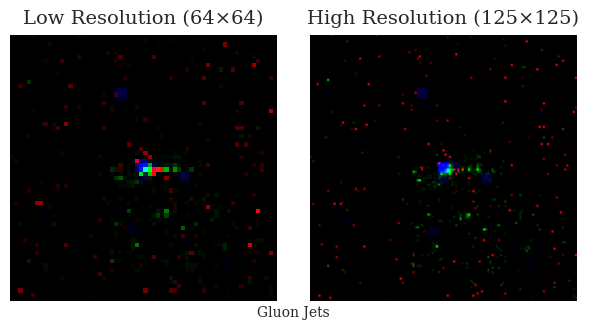

In [ ]:
import matplotlib.pyplot as plt


plt.style.use('seaborn-v0_8-white')

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

fig, axes = plt.subplots(1, 2, figsize=(6, 3), constrained_layout=True)


axes[0].imshow(img_lr)
axes[0].set_title("Low Resolution (64×64)", pad=8)
axes[0].axis("off")


axes[1].imshow(img_hr)
axes[1].set_title("High Resolution (125×125)", pad=8)
axes[1].axis("off")


for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)

fig.suptitle(
    "Gluon Jets",
    fontsize=10,
    y=0
)

plt.show()